<a href="https://colab.research.google.com/github/felipebrsm/PUC_Sprint_1_ML-FBRSM/blob/main/notebook/MVP_FBRSM_PUC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


#MVP: *Machine Learning & Analytics*

Modelo de Classificação de Dados Geotécnicos por *Random Forest* e *K-Means*

**Autor:** Felipe Barreto R. S. Macedo

**Data:** 05/07/2026

**Matrícula:** XXXXX

**Dataset:** Ex: Global Dataset of Cone Penetration Test Results - Jianye Ching (http://140.112.12.21/issmge/Database/Global_CPT_3_1196/Global_CPT_3_1196.zip)


---



## ✅ Checklist do MVP (o que precisa conter)
- [ ] **Problema definido** e contexto de negócio
- [ ] **Carga e preparação** dos dados (sem vazamento de dados)
- [ ] **Divisão** em treino/validação/teste (ou validação cruzada apropriada)
- [ ] **Tratamento**: limpeza, transformação e **engenharia de atributos**
- [ ] **Modelagem**: comparar abordagens/modelos (com **baseline**)
- [ ] **Otimização de hiperparâmetros**
- [ ] **Avaliação** com **métricas adequadas** e discussão de limitações
- [ ] **Boas práticas**: seeds fixas, tempo de treino, recursos computacionais, documentação
- [ ] **Pipelines reprodutíveis** (sempre que possível)



## 1. Escopo, objetivo e definição do problema

A classificação de tipos de solo é de fundamental importância para a Engenharia Geotécnica, sendo o ensaio de Penetração de Cone Piezométrico (CPT) uma das formas mais confiáveis de obtenção de dados subterrâneos, em particular para projetos submarinos.

O resultado do CPT fornece parâmetros que permitem avaliar granulometria do solo e calcular valores de resistência ao cisalhamento. Usualmente, é utilizado o método empírico de Robertson para classificação de solos (Soil Behavior Type), embora esse modelo seja generalista, muitas vezes não permitindo a avaliação de mudanças de comportamento local.

A proposta desse MVP é a criação de modelos que permitam:
- classificar camadas de solo a partir dos parâmetros do CPT;
- detecte interfaces em camadas;
- comparar com o modelo de Robertson, avaliando concordâncias, discordâncias e abrangência.

Para tanto, foi utilizado um dataset de resultados globais de CPT disponibilizado na internet. Os dados estão divididos por locação, organizados em planilhas .xlsx, e apresentam os parâmetros usuais de resultados de CPT:
- depth - Profundidade (m)
- qc - Resistência de ponta (MPa)
- fs - Atrito lateral (kPa)
- u2 - Poropressão (kPa)

Foram previstas as seguintes etapas:
1. Pré-processamento com compilação, padronização e normalização dos dados.
2. *Feature Engineering* com cálculo das tensões in-situ e dos índices normalizados.
3. Classificação supervisionada pelo modelo de Robertson (parâmetro Ic), servindo de base para a comparação dos modelos.
4. Modelagem não supervisionada por K-Means, com escolha de k por meio do Silhouette Score e método do cotovelo.
5. Modelagem por Random Forest supervisionada pelo método de Robertson, possibilitando predição e indicando a importância de cada feature.
6. Comparação entre K-Means, Random Forest e Robertson.

Como resultado, proponho um log CPT classificado para furos de teste, acompanhado de uma tabela de métricas comparando os dois modelos com Robertson — permitindo avaliar quantitativamente o quanto a classificação automática converge ou diverge do método tradicional.





## 2. Reprodutibilidade e ambiente
Especifique o ambiente. Por exemplo:
- Bibliotecas usadas.
- Seeds fixas para reprodutibilidade.

In [20]:
# ---- CÓDIGO REAL ----------#
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import classification_report, adjusted_rand_score, silhouette_score, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

print('Bibliotecas carregadas com sucesso.')

Bibliotecas carregadas com sucesso.


In [ ]:
# === Setup básico e reprodutibilidade ===
import os, random, time, sys, math
import numpy as np
import pandas as pd
import time
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, TimeSeriesSplit
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyClassifier, DummyRegressor
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.cluster import KMeans
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score, confusion_matrix,
                             mean_absolute_error, mean_squared_error, r2_score,
                             silhouette_score)

from sklearn.model_selection import StratifiedKFold, KFold, TimeSeriesSplit, RandomizedSearchCV
from scipy.stats import randint, uniform

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

# Para frameworks que suportam seed adicional (ex.: PyTorch/TensorFlow), documente aqui:
# import torch; torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
# import tensorflow as tf; tf.random.set_seed(SEED)

print("Python:", sys.version.split()[0])
print("Seed global:", SEED)

Python: 3.12.11
Seed global: 42



### 2.1 Dependências (opcional)
Instale pacotes extras se necessário. **Mantenha o projeto enxuto** para facilitar a correção.


2.1.a Instalações

In [ ]:
!pip install openpyxl -q

2.1.a Bibliotecas

In [3]:
import pandas as pd
import os
import shutil
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

### 2.2 Funções python (opcional)
Defina, se necessário, funções em Python para reutilizar seu código e torná-lo mais organizado. Essa é uma boa prática de programação que facilita a leitura, manutenção e evolução do seu projeto.


## 3. Dados: carga, entendimento e qualidade
**TODO:** descreva a origem dos dados, dicionário de variáveis e licença/ética quando aplicável.  
Evite **vazamento de dados**. Se usar feature store ou dados sintéticos, explique.


INCLUIR TEXTO EXPLICANDO PROCESSAMENTO

Leitura do Database

In [4]:
USUARIO = 'felipebrsm'
REPO    = 'PUC_Sprint_1_ML-FBRSM'
BRANCH  = 'main'
ARQUIVO = 'data/processed/dataset_compilado.csv'

URL = f'https://raw.githubusercontent.com/felipebrsm/PUC_Sprint_1_ML-FBRSM/refs/heads/main/data/processed/dataset_compilado.csv'

df = pd.read_csv(URL)

print(f'Shape: {df.shape}')
df.head()

Shape: (475083, 7)


,locacao,ensaio,pagina,depth,qc,fs,u2
0,@Aranui,1,工作表1,0.000000,0.4374,0.0,2.1
1,@Aranui,1,工作表1,0.010000,0.7282,0.0,2.1
2,@Aranui,1,工作表1,0.019999,0.6739,0.0,2.5
3,@Aranui,1,工作表1,0.029997,2.2015,0.0,2.3
4,@Aranui,1,工作表1,0.039996,2.6513,0.0,2.9


Resumo do Dataset

In [6]:

dataset = df

print('=' * 50)
print('RESUMO DO DATASET COMPILADO')
print('=' * 50)
print(f'Linhas totais  : {len(dataset):,}')
print(f'Locações       : {dataset["locacao"].nunique()}')
print(f'Ensaios únicos : {dataset[["locacao","ensaio"]].drop_duplicates().shape[0]}')
print(f'Abas únicas    : {dataset[["locacao","ensaio","pagina"]].drop_duplicates().shape[0]}')
print()
print('Ensaios por locação:')
print(dataset.groupby('locacao')['ensaio'].nunique().to_string())

RESUMO DO DATASET COMPILADO
Linhas totais  : 475,083
Locações       : 23
Ensaios únicos : 412
Abas únicas    : 412

Ensaios por locação:
locacao
@Aranui                                   11
@Avondale                                 33
@Avonside                                 12
@Bexley                                   14
@Camberley (hospital)                     12
@Cashmere (high school)                   16
@Christchurch (Central City)              36
@Christchurch (Cnr Armagh & Durham St)     6
@Christchurch (Metro Sports Facility)     15
@Christchurch (stadium)                   12
@Hastings (hospital)                      13
@Lower Hutt (town hall)                   29
@Marshland                                24
@Marshland (road)                         27
@New Brighton (Willryan Ave)              10
@Parkland (Bower Ave)ONE                   8
@Parkland (Bower Ave)TWO                  11
@Port Nelson                              27
@Redcliffs (Main road)                     7


Estatísticas

In [7]:
print('ESTATÍSTICAS DESCRITIVAS')
print(dataset[['depth','qc','fs','u2']].describe().round(3))
print()
print('VALORES NULOS')
nulos = dataset.isnull().sum()
print(nulos[nulos > 0] if nulos.any() else 'Nenhum valor nulo.')
print()
dataset.head()

ESTATÍSTICAS DESCRITIVAS
            depth          qc          fs           u2
count  475083.000  475083.000  472984.000   475083.000
mean        8.814       9.561      76.103      194.899
std         6.965       9.088     167.652    35535.280
min         0.000      -0.249   -7777.000   -90470.000
25%         3.487       2.140      27.700      -20.500
50%         6.993       6.950      56.500       14.000
75%        12.735      14.777      99.700       72.000
max       824.000      94.360    1674.000  9999000.000

VALORES NULOS
fs    2099
dtype: int64



,locacao,ensaio,pagina,depth,qc,fs,u2
0,@Aranui,1,工作表1,0.000000,0.4374,0.0,2.1
1,@Aranui,1,工作表1,0.010000,0.7282,0.0,2.1
2,@Aranui,1,工作表1,0.019999,0.6739,0.0,2.5
3,@Aranui,1,工作表1,0.029997,2.2015,0.0,2.3
4,@Aranui,1,工作表1,0.039996,2.6513,0.0,2.9


Limpeza

In [8]:
# Remove primeiros 0.5m (fs frequentemente zerado por falta de contato)
df = df[df['depth'] >= 0.5].copy()

# Clipa valores negativos de fs (erro de medição)
df['fs'] = df['fs'].clip(lower=0)

# Remove qc <= 0 (fisicamente impossível)
df = df[df['qc'] > 0].copy()

print(f'Linhas após limpeza: {len(df):,}')

Linhas após limpeza: 461,938


Avaliação visual do balanceamento

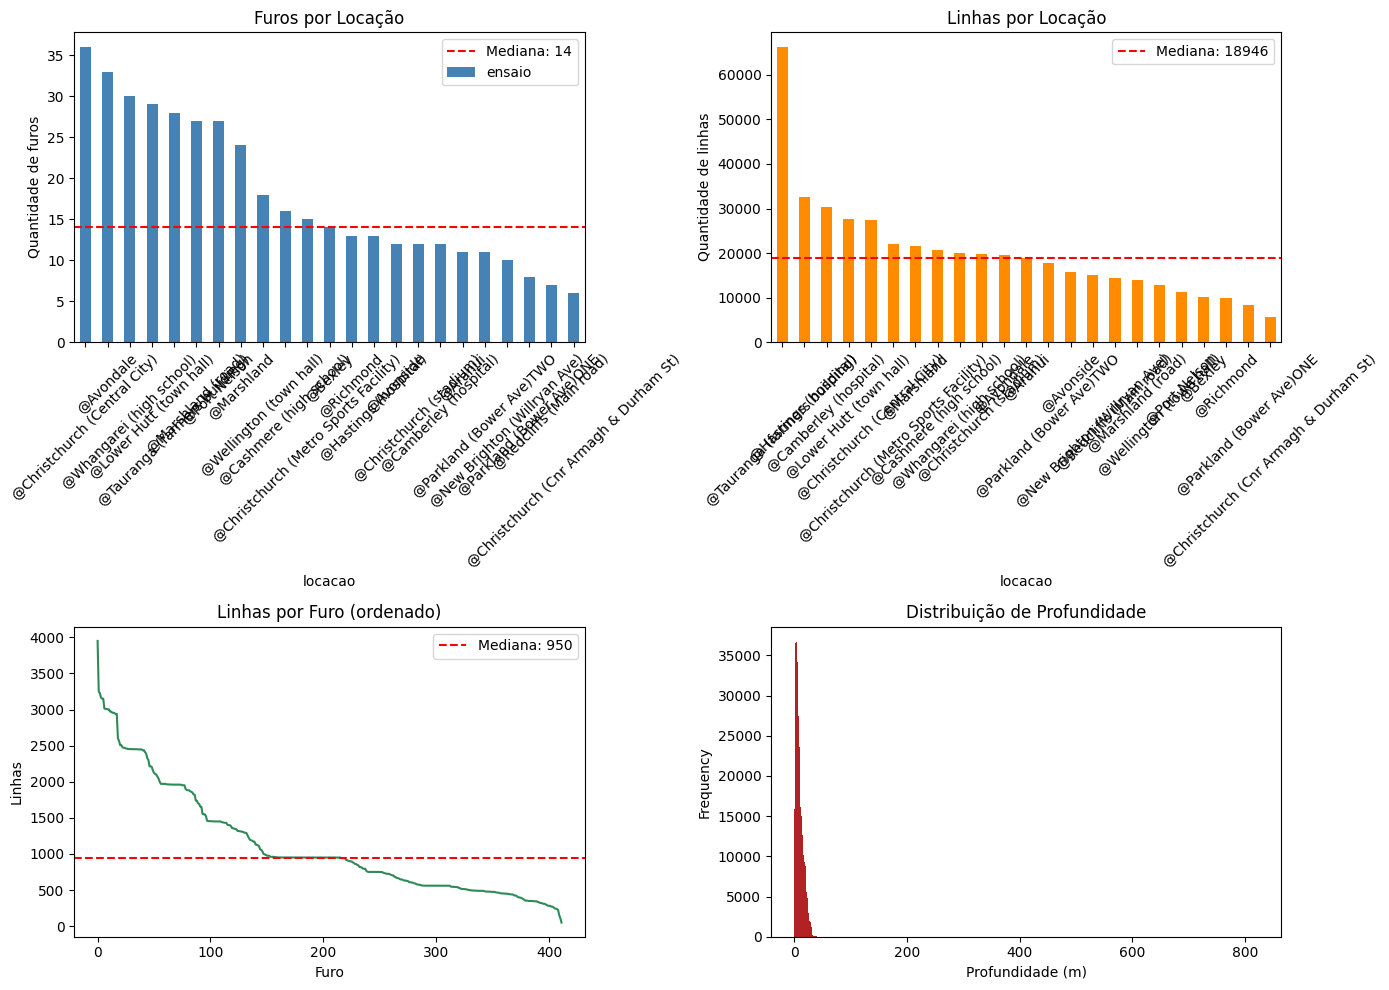

Razão furos max/min  : 6.00x
Razão linhas max/min : 11.57x


In [11]:
furos_por_locacao  = df.groupby('locacao')['ensaio'].nunique().sort_values(ascending=False)
linhas_por_locacao = df.groupby('locacao').size().sort_values(ascending=False)
linhas_por_furo     = df.groupby(['locacao','ensaio']).size().sort_values(ascending=False)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

furos_por_locacao.plot(kind='bar', ax=axes[0,0], color='steelblue')
axes[0,0].axhline(y=furos_por_locacao.median(), color='red', linestyle='--',
                  label=f'Mediana: {furos_por_locacao.median():.0f}')
axes[0,0].set_title('Furos por Locação')
axes[0,0].set_ylabel('Quantidade de furos')
axes[0,0].tick_params(axis='x', rotation=45)
axes[0,0].legend()

linhas_por_locacao.plot(kind='bar', ax=axes[0,1], color='darkorange')
axes[0,1].axhline(y=linhas_por_locacao.median(), color='red', linestyle='--',
                  label=f'Mediana: {linhas_por_locacao.median():.0f}')
axes[0,1].set_title('Linhas por Locação')
axes[0,1].set_ylabel('Quantidade de linhas')
axes[0,1].tick_params(axis='x', rotation=45)
axes[0,1].legend()

linhas_por_furo.reset_index(drop=True).plot(ax=axes[1,0], color='seagreen')
axes[1,0].axhline(y=linhas_por_furo.median(), color='red', linestyle='--',
                  label=f'Mediana: {linhas_por_furo.median():.0f}')
axes[1,0].set_title('Linhas por Furo (ordenado)')
axes[1,0].set_xlabel('Furo')
axes[1,0].set_ylabel('Linhas')
axes[1,0].legend()

df['depth'].plot(kind='hist', bins=np.arange(0, df['depth'].max()+1, 1.0), ax=axes[1,1], color='firebrick')
axes[1,1].set_title('Distribuição de Profundidade')
axes[1,1].set_xlabel('Profundidade (m)')

plt.tight_layout()
plt.show()

print(f'Razão furos max/min  : {furos_por_locacao.max()/furos_por_locacao.min():.2f}x')
print(f'Razão linhas max/min : {linhas_por_locacao.max()/linhas_por_locacao.min():.2f}x')

Estratégia de Balanceamento

In [ ]:
## 5. Estratégia de correção do desbalanceamento

Aplicamos undersampling em duas etapas:
1. Limita o número de **furos** por locação à mediana — locações com mais furos têm uma amostra aleatória de furos inteiros selecionada, preservando a integridade de cada perfil CPT.
2. Limita o número de **linhas** por furo à mediana — furos muito longos têm seus pontos reduzidos por amostragem aleatória.

Usamos a mediana (e não a média) por ser mais robusta a outliers — locações ou furos extremos não distorcem o valor de referência.

In [12]:
SEED = 42

# Passo 1 — limita furos por locação
mediana_furos = int(df.groupby('locacao')['ensaio'].nunique().median())

furos_selecionados = (
    df.groupby('locacao')['ensaio']
      .unique()
      .reset_index()
      .apply(lambda row: pd.Series({
          'locacao': row['locacao'],
          'ensaio' : list(row['ensaio'])
                     if len(row['ensaio']) <= mediana_furos
                     else list(pd.Series(row['ensaio']).sample(mediana_furos, random_state=SEED))
      }), axis=1)
      .explode('ensaio')
)

df_bal = df.merge(furos_selecionados, on=['locacao', 'ensaio'])

# Passo 2 — limita linhas por furo
mediana_linhas = int(df_bal.groupby(['locacao','ensaio']).size().median())

df_bal = (
    df_bal.groupby(['locacao', 'ensaio'], group_keys=False)
          .apply(lambda x: x.sample(min(len(x), mediana_linhas), random_state=SEED))
          .reset_index(drop=True)
)

linhas_final = df_bal.groupby('locacao').size()

print(f'Mediana de furos por locação  : {mediana_furos}')
print(f'Mediana de linhas por furo    : {mediana_linhas}')
print()
print(f'Linhas antes do balanceamento : {len(df):,}')
print(f'Linhas depois do balanceamento: {len(df_bal):,}')
print(f'Razão max/min (linhas/locação): {linhas_final.max()/linhas_final.min():.2f}x')

Mediana de furos por locação  : 14
Mediana de linhas por furo    : 951

Linhas antes do balanceamento : 461,938
Linhas depois do balanceamento: 224,722
Razão max/min (linhas/locação): 3.23x


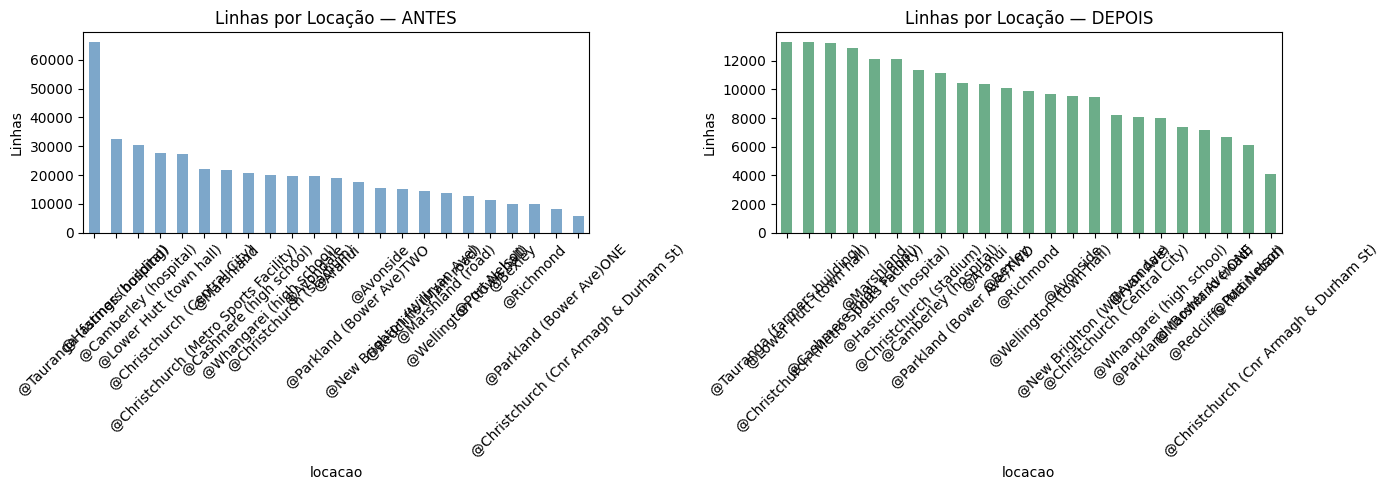

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

linhas_por_locacao.plot(kind='bar', ax=axes[0], color='steelblue', alpha=0.7)
axes[0].set_title('Linhas por Locação — ANTES')
axes[0].set_ylabel('Linhas')
axes[0].tick_params(axis='x', rotation=45)

linhas_final.sort_values(ascending=False).plot(kind='bar', ax=axes[1], color='seagreen', alpha=0.7)
axes[1].set_title('Linhas por Locação — DEPOIS')
axes[1].set_ylabel('Linhas')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# A partir daqui o dataset balanceado substitui o original
df = df_bal.copy()

## 6. Feature Engineering

Cálculo das tensões in situ e dos índices normalizados de Robertson (Qt, Fr, Bq, Ic), que removem o efeito do aumento de tensão com a profundidade.

In [14]:
GAMMA   = 18.0   # kN/m3 - peso especifico do solo
GAMMA_W = 9.81   # kN/m3 - peso especifico da agua

df['sigma_v0']     = GAMMA   * df['depth']
df['u0']           = GAMMA_W * df['depth']
df['sigma_v0_eff'] = df['sigma_v0'] - df['u0']
df['delta_u']      = df['u2'] - df['u0']
df['qc_kpa']       = df['qc'] * 1000

df = df[df['sigma_v0_eff'] > 0].copy()
df = df[(df['qc_kpa'] - df['sigma_v0']) > 0].copy()

df['Qt'] = (df['qc_kpa'] - df['sigma_v0']) / df['sigma_v0_eff']
df['Fr'] = (df['fs'] / (df['qc_kpa'] - df['sigma_v0'])) * 100
df['Bq'] = df['delta_u'] / (df['qc_kpa'] - df['sigma_v0'])

df['Fr'] = df['Fr'].clip(lower=0.01)
df['Qt'] = df['Qt'].clip(lower=0.01)

df['Ic'] = np.sqrt(
    (3.47 - np.log10(df['Qt']))**2 +
    (np.log10(df['Fr']) + 1.22)**2
)

df[['Qt','Fr','Bq','Ic']].describe().round(3)

,Qt,Fr,Bq,Ic
count,224552.000,223487.000,224552.000,223487.000
mean,236.889,1.464,0.027,1.846
std,324.737,4.160,2.453,0.580
min,0.022,0.010,-10.909,0.109
25%,65.835,0.508,-0.015,1.449
50%,156.061,0.767,-0.005,1.704
75%,273.988,1.608,-0.001,2.218
max,8847.883,1059.851,544.900,6.440


## 7. Rótulos Robertson (referência)

In [15]:
def robertson_label(ic):
    if   ic < 1.31: return 7   # Areia densa / cascalho
    elif ic < 2.05: return 6   # Areia limpa
    elif ic < 2.60: return 5   # Areia siltosa
    elif ic < 2.95: return 4   # Silte arenoso
    elif ic < 3.60: return 3   # Argila siltosa
    else:           return 2   # Argila orgânica

NOMES_SBT = {
    2: 'Argila orgânica',
    3: 'Argila siltosa',
    4: 'Silte arenoso',
    5: 'Areia siltosa',
    6: 'Areia limpa',
    7: 'Areia densa'
}

df['SBT']      = df['Ic'].apply(robertson_label)
df['SBT_nome'] = df['SBT'].map(NOMES_SBT)

## 8. Holdout único, Cross-Validation e Normalização sem leakage

Esta seção centraliza todo o controle de vazamento de dados do notebook. Princípios aplicados:

- **Um único holdout** (80% treino / 20% teste) é criado aqui e reaproveitado por **ambos** os modelos — Random Forest e KMeans — garantindo que nenhum modelo veja, em qualquer etapa, uma linha do conjunto de teste antes da avaliação final.
- **StandardScaler** é ajustado (`fit`) **apenas no treino**. O teste passa só por `transform`, nunca por `fit` — assim a média e o desvio usados na normalização não "veem" os dados de teste.
- **Cross-Validation** (5-fold estratificado) roda inteiramente dentro do treino, antes de qualquer contato com o holdout.
- O **KMeans**, embora não supervisionado, também é ajustado apenas com `X_train_scaled` — os clusters de teste são obtidos por `predict`, nunca recalculando os centróides com dados de teste.


## 4. Definição do target, variáveis e divisão dos dados
**TODO:** escolha o **target** (ou defina a tarefa de clusterização/forecast).  
- Em **séries temporais**, **não embaralhe** e use divisões temporais (ex.: `TimeSeriesSplit`).
- Em **classificação desequilibrada**, considere **estratégias para desbalanceamento** (ex.: `class_weight`, undersampling/oversampling).

> **Atenção:** Todas as **transformações** aprendidas devem ser **ajustadas no treino** e **aplicadas no validação/teste**. Recomendamos usar **pipelines**. *italicized text*


## 8. Holdout único, Cross-Validation e Normalização sem leakage

Esta seção centraliza todo o controle de vazamento de dados do notebook. Princípios aplicados:

- **Um único holdout** (80% treino / 20% teste) é criado aqui e reaproveitado por **ambos** os modelos — Random Forest e KMeans — garantindo que nenhum modelo veja, em qualquer etapa, uma linha do conjunto de teste antes da avaliação final.
- **Ic é excluído das features.** O rótulo `SBT` é calculado diretamente a partir de `Ic` (`robertson_label(ic)`), então incluir `Ic` como feature causaria vazamento direto entre rótulo e entrada — o modelo aprenderia a decorar os limiares da fórmula em vez de aprender o padrão de solo. Por isso `FEATURES = ['Qt', 'Fr', 'Bq']`.
- **StandardScaler** é ajustado (`fit`) **apenas no treino**. O teste passa só por `transform`, nunca por `fit` — assim a média e o desvio usados na normalização não "veem" os dados de teste.
- **Cross-Validation** (5-fold estratificado) roda inteiramente dentro do treino, antes de qualquer contato com o holdout.
- O **KMeans**, embora não supervisionado, também é ajustado apenas com `X_train_scaled` — os clusters de teste são obtidos por `predict`, nunca recalculando os centróides com dados de teste.

In [24]:
# Dois conjuntos de features, mesmo holdout:
#
# FEATURES_RF — variaveis BRUTAS do CPT (Opcao B). O Random Forest aprende
# a relacao fisica direta entre as medicoes originais e o tipo de solo,
# sem nenhum indice pre-calculado que possa expor o rotulo.
#
# FEATURES_KM — indices normalizados de Robertson, sem Ic (Ic define o
# rotulo SBT diretamente, entao seria vazamento tambem para o KMeans).
FEATURES_RF = ['depth', 'qc', 'fs', 'u2']
FEATURES_KM = ['Qt', 'Fr', 'Bq']

X  = df[FEATURES_RF]      # usado no holdout / RF / cross-validation
Xk = df[FEATURES_KM]      # usado apenas no KMeans, mesmo split de linhas
y  = df['SBT']

# ─── Holdout único — usado por Random Forest e KMeans ──────────────────
# Mantemos também o índice original do df para recuperar 'cluster' e
# 'SBT_nome' nas linhas corretas mais adiante.
X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X, y, df.index,
    test_size=0.2, random_state=42, stratify=y
)

# Mesmo split de linhas (via idx_train/idx_test), aplicado ao conjunto
# de features do KMeans — garante que treino e teste sejam consistentes
# entre os dois modelos.
Xk_train = Xk.loc[idx_train]
Xk_test  = Xk.loc[idx_test]

print(f'Treino : {len(X_train):,} linhas')
print(f'Teste  : {len(X_test):,} linhas')
print()
print('Proporção de classes — treino:')
print((y_train.value_counts(normalize=True) * 100).round(1))
print()
print('Proporção de classes — teste:')
print((y_test.value_counts(normalize=True) * 100).round(1))

Treino : 179,641 linhas
Teste  : 44,911 linhas

Proporção de classes — treino:
SBT
6    53.5
5    18.2
7    15.0
4     7.4
3     5.1
2     0.7
Name: proportion, dtype: float64

Proporção de classes — teste:
SBT
6    53.5
5    18.2
7    15.0
4     7.4
3     5.1
2     0.7
Name: proportion, dtype: float64


In [25]:
# ─── StandardScaler sem leakage (apenas para o KMeans) ──────────────────
# O Random Forest usa variaveis brutas (depth, qc, fs, u2) sem escala —
# arvores de decisao nao precisam de normalizacao. O StandardScaler aqui
# normaliza Xk (Qt, Fr, Bq), que sera usado exclusivamente pelo KMeans.
#
# fit_transform SOMENTE no treino: o scaler aprende média e desvio
# olhando apenas para os dados de treino.
scaler = StandardScaler()
Xk_train_scaled = scaler.fit_transform(Xk_train)

# transform (sem fit) no teste: aplica a média/desvio já aprendidos,
# sem deixar o teste influenciar a escala.
Xk_test_scaled = scaler.transform(Xk_test)

print('Média do treino (deve ser ~0 após scaling):')
print(pd.DataFrame(Xk_train_scaled, columns=FEATURES_KM).mean().round(3))
print()
print('Média do teste (não necessariamente 0 — usa a escala do treino):')
print(pd.DataFrame(Xk_test_scaled, columns=FEATURES_KM).mean().round(3))

Média do treino (deve ser ~0 após scaling):
Qt   -0.0
Fr    0.0
Bq    0.0
dtype: float64

Média do teste (não necessariamente 0 — usa a escala do treino):
Qt   -0.012
Fr   -0.009
Bq    0.005
dtype: float64



## 5. Tratamento de dados e **Pipeline** de pré-processamento
Crie um **Pipeline** com as etapas necessárias (limpeza, imputação, encoding, escala, seleção de atributos, etc.)  
Isso garante **reprodutibilidade** e evita **vazamento**.


Acurácia por fold: [0.982 0.981 0.984 0.983 0.983]
Média : 0.983
Desvio: 0.001


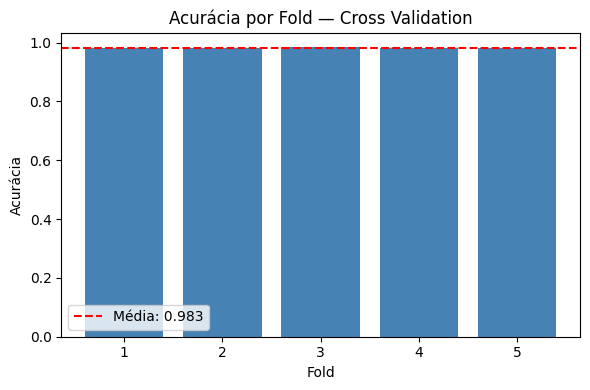

In [26]:
# ─── Cross-Validation — inteiramente dentro do treino ──────────────────
# Cada fold do CV faz seu próprio fit do scaler dentro do Pipeline,
# evitando leakage entre os folds de validação.
from sklearn.pipeline import Pipeline

pipeline_rf = Pipeline([
    ('scaler', StandardScaler()),
    ('rf', RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42))
])

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(pipeline_rf, X_train, y_train, cv=skf, scoring='accuracy')

print('Acurácia por fold:', np.round(scores, 3))
print(f'Média : {scores.mean():.3f}')
print(f'Desvio: {scores.std():.3f}')

plt.figure(figsize=(6,4))
plt.bar(range(1, 6), scores, color='steelblue')
plt.axhline(y=scores.mean(), color='red', linestyle='--', label=f'Média: {scores.mean():.3f}')
plt.title('Acurácia por Fold — Cross Validation')
plt.xlabel('Fold')
plt.ylabel('Acurácia')
plt.legend()
plt.tight_layout()
plt.show()

> **Nota sobre as features do Random Forest:** `X_train`/`X_test` agora contêm as variáveis brutas do CPT (`depth`, `qc`, `fs`, `u2`) — a Opção B discutida anteriormente. O modelo aprende a relação física direta entre as medições originais e o tipo de solo, sem depender de nenhum índice pré-calculado (Qt, Fr, Bq, Ic) que poderia carregar informação correlata ao próprio rótulo. Por não precisar de escala, nenhum `StandardScaler` é usado aqui.

> **Nota sobre a acurácia esperada:** com features brutas em vez dos índices normalizados, espera-se uma acurácia ainda mais conservadora do que com `Qt, Fr, Bq` — o modelo precisa reconstruir, a partir dos dados crus, o mesmo padrão que a fórmula de Robertson calcula explicitamente. Resultado significativamente abaixo de 1.000 é esperado e correto.

## 9. Modelo supervisionado — Random Forest (avaliação final no holdout)

In [27]:
# Random Forest final treinado nos dados de treino (sem escala — árvores não precisam)
rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           2       0.99      0.97      0.98       325
           3       0.98      0.97      0.97      2276
           4       0.96      0.95      0.96      3337
           5       0.97      0.98      0.97      8194
           6       0.99      0.99      0.99     24028
           7       0.99      0.98      0.98      6751

    accuracy                           0.98     44911
   macro avg       0.98      0.97      0.98     44911
weighted avg       0.98      0.98      0.98     44911



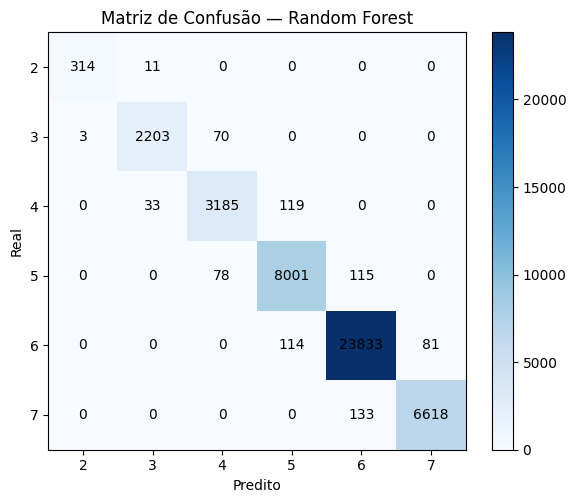

In [28]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(6,5))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks(range(len(sorted(y.unique()))))
ax.set_yticks(range(len(sorted(y.unique()))))
ax.set_xticklabels(sorted(y.unique()))
ax.set_yticklabels(sorted(y.unique()))
ax.set_xlabel('Predito')
ax.set_ylabel('Real')
ax.set_title('Matriz de Confusão — Random Forest')
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i,j], ha='center', va='center')
plt.colorbar(im)
plt.tight_layout()
plt.show()

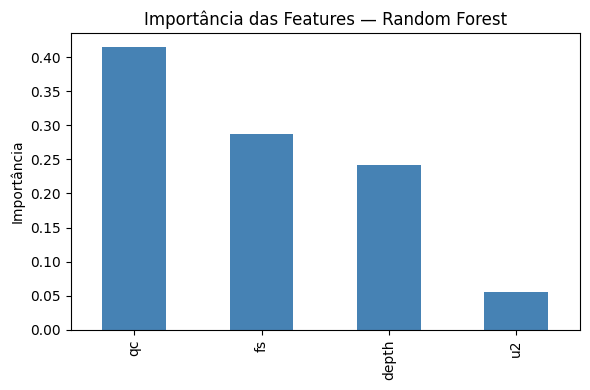

In [29]:
importancias = pd.Series(rf.feature_importances_, index=FEATURES_RF).sort_values(ascending=False)
importancias.plot(kind='bar', color='steelblue', figsize=(6,4))
plt.title('Importância das Features — Random Forest')
plt.ylabel('Importância')
plt.tight_layout()
plt.show()

## 10. Modelo não supervisionado — KMeans (mesmo holdout, sem leakage)

O KMeans usa **Xk_train_scaled** — os índices `Qt, Fr, Bq` já normalizados apenas com a escala do treino — para encontrar os centróides. Os pontos de teste recebem cluster via `predict`, reaproveitando os centróides aprendidos — nenhum dado de teste participa do cálculo dos centróides. Note que o KMeans usa um conjunto de features diferente do Random Forest: `FEATURES_KM` (índices normalizados), enquanto o RF usa `FEATURES_RF` (variáveis brutas) — ambos derivados do mesmo holdout de linhas.

### Busca de hiperparâmetro — número de clusters (k)

O `GridSearchCV` do scikit-learn não se aplica diretamente ao KMeans porque ele foi desenhado para modelos supervisionados, que usam `cross_val_score` comparando predição com rótulo verdadeiro. Para um algoritmo não supervisionado, fazemos a busca manualmente: testamos uma faixa de valores de `k`, sempre **dentro do treino**, e avaliamos cada um por duas métricas:

- **Silhouette Score** — não depende de rótulos, mede o quão bem definidos estão os clusters.
- **ARI vs Robertson** — usa o rótulo apenas para comparação posterior, não para treinar o modelo.

O `k` final é escolhido a partir dessas curvas e só então aplicado ao holdout de teste.

In [30]:
# ─── Grid manual de k — inteiramente dentro do treino ──────────────────
K_RANGE = range(2, 12)

resultados_k = []
for k in K_RANGE:
    km_k = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_k = km_k.fit_predict(Xk_train_scaled)

    sil_k = silhouette_score(Xk_train_scaled, labels_k)
    ari_k = adjusted_rand_score(y_train, labels_k)

    resultados_k.append({'k': k, 'inertia': km_k.inertia_, 'silhouette': sil_k, 'ari': ari_k})

df_k = pd.DataFrame(resultados_k)
df_k

ValueError: Input X contains NaN.
KMeans does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

axes[0].plot(df_k['k'], df_k['inertia'], marker='o', color='steelblue')
axes[0].set_title('Método do Cotovelo')
axes[0].set_xlabel('k')
axes[0].set_ylabel('Inércia')

axes[1].plot(df_k['k'], df_k['silhouette'], marker='o', color='darkorange')
axes[1].set_title('Silhouette Score (maior = melhor)')
axes[1].set_xlabel('k')
axes[1].set_ylabel('Silhouette')

axes[2].plot(df_k['k'], df_k['ari'], marker='o', color='seagreen')
axes[2].axvline(x=6, color='red', linestyle='--', label='k=6 (zonas Robertson)')
axes[2].set_title('ARI vs Robertson')
axes[2].set_xlabel('k')
axes[2].set_ylabel('ARI')
axes[2].legend()

plt.tight_layout()
plt.show()

print(f"Melhor k por Silhouette : {df_k.loc[df_k['silhouette'].idxmax(), 'k']}")
print(f"Melhor k por ARI        : {df_k.loc[df_k['ari'].idxmax(), 'k']}")

> **Como escolher k:** o método do cotovelo indica onde a redução de inércia desacelera; o Silhouette aponta o k com clusters mais bem separados; o ARI mostra qual k mais se aproxima das 6 zonas de Robertson. Esses critérios podem apontar para valores diferentes — isso é esperado e informativo: se o k ideal por Silhouette não for 6, é evidência de que a estrutura natural dos dados não corresponde exatamente às zonas de Robertson. Ajuste `K_FINAL` abaixo com base nessa análise.

In [ ]:
# Defina aqui o k escolhido a partir da análise acima
K_FINAL = 6

# fit apenas no treino — os centroides sao calculados sem ver o teste
km = KMeans(n_clusters=K_FINAL, random_state=42, n_init=10)
cluster_train = km.fit_predict(Xk_train_scaled)

# predict (sem fit) no teste — reaproveita os centroides ja calculados
cluster_test = km.predict(Xk_test_scaled)

sil_train = silhouette_score(Xk_train_scaled, cluster_train)
ari_train = adjusted_rand_score(y_train, cluster_train)
ari_test  = adjusted_rand_score(y_test, cluster_test)

print(f'k escolhido                 : {K_FINAL}')
print(f'Silhouette Score (treino)   : {sil_train:.3f}')
print(f'ARI vs Robertson (treino)   : {ari_train:.3f}')
print(f'ARI vs Robertson (teste)    : {ari_test:.3f}')
print()
print('Diferença treino-teste indica se os clusters generalizam bem')
print(f'Diferença ARI : {abs(ari_train - ari_test):.3f}')

In [ ]:
# Reincorpora os clusters ao dataframe original, nas linhas corretas
df.loc[idx_train, 'cluster'] = cluster_train
df.loc[idx_test,  'cluster'] = cluster_test
df['cluster'] = df['cluster'].astype(int)

df['cluster'].value_counts().sort_index()

## 11. Comparação final

In [ ]:
tabela = pd.crosstab(df['SBT_nome'], df['cluster'], rownames=['Robertson'], colnames=['Cluster KMeans'])
tabela


## 6. Baseline e modelos candidatos
Se possivek, comece com uma **baseline simples** (ex.: DummyClassifier/Regressor) e evolua para modelos mais fortes. O baseline pode ser seu primeiro modelo!  

**Compare** ao menos **duas abordagens**.

> Para **deep learning** (visão computacional/NLP/séries), crie uma seção específica (p. ex., `TensorFlow`/`PyTorch`) e documente arquitetura, parâmetros e tempo de treino.



### 6.1 Treino e avaliação rápida (baseline vs candidatos)
Use **métricas adequadas** ao tipo de problema. Documente suas observações.



## 7. Validação e Otimização de Hiperparâmetros
Use **validação cruzada** apropriada ao problema (Ex: **`StratifiedKFold`** para classificação; **`KFold`** para regressão).  
Faça **tuning** com `GridSearchCV`/`RandomizedSearchCV`.



## 8. Avaliação final, análise de erros e limitações
- **Compare** baseline vs melhor modelo.  
- Faça **análise de erros** (ex.: matriz de confusão, casos pior previstos, resíduos).  
- Discuta **limitações**: dados, métricas, viés, generalização.



## 9. Engenharia de atributos (detalhe)
**TODO:** Documente as escolhas: seleção/extração, encoding, criação de variáveis temporais (lags, médias móveis), TF-IDF/embeddings (NLP), augmentations (visão), etc.



## 10. (Opcional) Deep Learning / Fine-tuning
Se usar DL, descreva: arquitetura, hiperparâmetros, _early stopping_, tamanho do batch, épocas, e se houve **fine-tuning** de modelos pré-treinados.



## 11. Boas práticas e rastreabilidade
- **Baseline** claro e justificativas para melhorias.  
- **Pipelines** (evitar vazamento).  
- **Decisões de projeto** documentadas (o que tentou e por quê).



## 12. Conclusões e próximos passos
**TODO:** Resuma resultados, trade-offs, e proponha melhorias futuras (mais dados, features, modelos, tuning).



## 13. Salvando artefatos (modelos e pipeline)
Se o treinamento dos modelos demora mais de 3 minutos, recomendamos salvar o **modelo/pipeline** após o treinamento e depois apenas carregar o arquivo (ex: .pkl, .h5) salvo em outra célula, sem precisar treinar novamente.  